## this is still pending 
cramers'v from misbahullah sir video session 3 , time 33.50
hypothesis testing during univariate analysis from misbahulah sir video session 3 , time 41.20

# correct order is:  
Order may change sometimes, as I am working on real estate dataset hence I am following this below order

1. Data cleaning:  
  a. change column names   
  b. drop duplicate rows,columns  
  c.column wise cleaning and so like :campusx capstone project 3 swiggy delivery prediction video, In that sir says that,the way they use for data cleaning that will help into DVC pipeline , and also sir create a function for data cleaning so if messy data given to it then it gives us clean data  
  d.this can be very good way we can try: run baseline model on with and without imputation data(shown in campusx capstone project 3 swiggy delivery prediction-in session 4)

2. Build a Baseline model  
3. we have to perform diff experiments


5. **Missing values imputation** → Handle missing data first to avoid issues in later steps(BP153,BP154, BP158, BP159, BP160)(note:BP153(here in BP153 sir face issue in his process which they solve in BP154),BP154,BP160 so in this you will see how effectively we can use feature union ,CT and pipeline) . read optuna and Bayesian optimization also becoz this is helpful for you in this missing value imputation part read (BP168 onwards) for that and also there two different techniques(using column transformer, feature union and pipeline) use by campusx sir to solve the problem so see that in BP160, and also refer mohammed sir -AWS sagemaker video in that watch session 5 (for same thing- function transformer, column transformer, feature union and pipeline )
Sometimes we do 1st outlier detection then missing values imputation but that also depend on data ,  
Eg: If outliers are obviously incorrect (e.g., negative age values), you may want to remove them before imputation.  
   - If using outlier-sensitive methods (mean, KNN), detect and handle outliers first.  
   - If using robust methods (median, most frequent), impute first, then remove outliers.
4. **group rare categories** - Group rare categories means combining values that appear very few times into one new group to simplify the data and avoid overfitting.
6. **Outlier removal** → Remove extreme values after imputation, as missing value treatment might introduce new outliers. (BP163)   
7. **Feature transformation** → Apply transformations like log transformation,Square Root ,Square,box cox,reciprocal Transformation(BP164), Assign weightages if necessary (e.g., location-based price adjustments) etc.   
8. hypothesis testing : apply test like f-test , ANOVA test  
9. **Discretization or Binning** and in this there is types of binning please search on gpt (BP156, BP157) : If you plan to turn continuous variables into categorical bins (e.g., quantile bins), it may reduce usefulness for PCA so try to analyse the result with and without this method  
10. **Feature encoding** → Convert categorical variables into numerical format for model compatibility. (One-Hot Encoding, Label Encoding, etc.) (BP152, BP155, BP156)  
    (liner models doesnt work well on ordinal encoded features but tree base models do)  
    so if categorical columns we not able to impute using mode and constant then we have to use encoding 1st eg:suppose we use target encoding then we can keep or impute the missing value using this encoding technique, if we keep the missing values then we can use imputation technique and then we can use outlier detection and removal also (I have use this in my property project)   
12. **Feature scaling** → Apply scaling because it's important before PCA, SVD, t-SNE. Use StandardScaler, MinMaxScaler, etc. (BP161, BP162)  
13. **Feature extraction** → Derive new features from existing ones (e.g., PCA, t-SNE, SVD, text embeddings).  
       **Note:** If not applying PCA, t-SNE, SVD, or text embeddings, then:  
       – Feature selection can be done **before or after scaling**, depending on the method.  
       – **Before scaling** if using raw stats (Variance Threshold, F-test, ANOVA, Chi-square test)  
       – **After scaling** if using model-based methods (RFE, Lasso, Ridge, Tree-based models, SHAP)  
14. **Hypothesis testing**  
15. **Feature selection** → Remove irrelevant or redundant features using methods like mutual information, RFE, or SHAP values.  
    in capstone project 1, property project, sir take mean fehature importance of all 8 techniques in session7 time 47.00  
    now suppose out of 8 columns 3 are not imp so we can drop them, so before doing that run exp as with and without that 3 columns to prove that this 3 columns are not that imp
        Use statistical tests (F-test, ANOVA) for selecting numerical features.  
        *Optional step. Do before or after PCA, depending on goal.*  
16. **Imbalanced data handling** → Undersampling and oversampling (BP165 ahead)  
17. **Hypothesis testing**
18. **baseline model**
19. **Model training**  

  Skewness Range             | Suggested Transformation  
---------------------------------------------------------------------
  0 to +1   (mild right)--------------->Square root or log  
  +1 to +3  (moderate right)----------->Log or Power Transform (Box-Cox / Yeo-Johnson)  
  `> +3      (strong right)`----------->Reciprocal or Power Transform (Box-Cox)  
  -1 to 0   (mild left)---------------->Square or reflect + square root  
  < -1      (strong left)-------------->Reflect + log or Power Transform (Yeo-Johnson)


## imp points for transformation  

- To check which transformation to apply, use: pd.DataFrame.skew()  
- If data is already normally distributed → do not apply any transformation  
- For tree-based algorithms, transformation is not required  
- For linear-based algorithms, transformation is often helpful  
- After transformation, results won’t always improve — test and verify  
- Box-Cox requires positive values only.    
- Yeo-Johnson works with zero or negative values too.     
- Always visualize (histogram/KDE/QQ-plot) after transforming.  

# Experiments I am going to perform:     

1) imputation and no outlier detection and removal ,apply transformation    
    - apply LR   
    - apply RF  
    - apply RF without transformation(this becoz for tree based algos transformation is not necessary)  
3) imputation then outlier detection and removal    
5) outlier detection and them imputation    
6) missing indicator - I think I will not make separate exp for this      
7)

Missing Value Imputation  
Outlier Removal  
Feature Transformation  
Feature Encoding  
Feature Extraction  
Feature Selection  
Feature Scaling  
Imbalanced Data Handling  
Model Training

imp points   
log transformed price column as it it is skewed and we have to do prediction on this log transformed price column only   
apply standardization on columns

# for amenities column

Great question. Since you're working on **property price prediction** and have a numerical feature `assigned_amenities_score` with **\~45% missing values**, and you've already added a **missing indicator**, here are your **next best options** — depending on your modeling goals and assumptions:

---

### ✅ 1. **Impute the missing values**

Even though you've added the missing indicator, models still need a filled numeric value. You can now apply **imputation**, ideally **alongside** the indicator:

#### Options:

* **Mean / Median**: Simple and fast.
* **KNN Imputer**: Learns from similar rows (good if features are correlated).
* **Iterative Imputer (MICE)**: Models missing values with regression trees or linear models.
* **LightGBM Regressor Imputer**: More powerful, though custom-coded.

```python
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # or 'median', or use KNN/Iterative
```

---

### ✅ 2. **Keep it as-is for tree models**

If you're using models like **XGBoost**, **LightGBM**, or **CatBoost**, and you've:

* **Added missing indicator**
* **Used a simple imputation like -999 or mean**

Then those models will **learn the missing pattern** internally. So no need for fancy imputation unless validation score improves.

---

### ✅ 3. **Apply transformations**

Once imputed, you can improve feature quality:

* **StandardScaler / MinMaxScaler** (if model is sensitive to scale: e.g., linear regression, SVR)
* **QuantileTransformer / RobustScaler** (if there are outliers)
* **Log-transform** if it's right-skewed:

  ```python
  df['assigned_amenities_score_log'] = np.log1p(df['assigned_amenities_score'])
  ```

---

### ✅ 4. **Binning / Discretization**

Convert the score into **ordinal bins** or **quantiles** (e.g., low, medium, high amenities):

```python
df['amenities_binned'] = pd.qcut(df['assigned_amenities_score'], q=4, labels=[0,1,2,3])
```

This can help tree models and categorical models interpret the feature better.

---

### ✅ 5. **Interaction Features**

Combine with other location/amenity variables:

```python
df['amenities_score_per_unit'] = df['assigned_amenities_score'] / df['available_units']
```

Or:

```python
df['amenities_parking_ratio'] = df['assigned_amenities_score'] / (df['parking'] + 1)
```

---

### ✅ 6. **Use SHAP or feature importance**

Once your pipeline is built, assess if `assigned_amenities_score` is truly **useful**. If it’s not important despite preprocessing, consider dropping it.

---

### 🔄 Suggested Pipeline Steps:

```python
amenity_score_transformer = Pipeline(steps=[
    ('add_missing_indicator', AmenitiesMissingIndicatorAdder()),  # step 1
    ('imputer', SimpleImputer(strategy='mean')),                 # step 2
    ('scaler', StandardScaler())                                 # step 3 (optional)
])
```

---

Let me know if you want this packed into a `ColumnTransformer` or need Optuna to optimize the imputer for it.


# notes for MCAR,MAR and MNAR

**MCAR: Missing data probability does not depend either on observed data or unobserved data.**

So suppose we have Gender and Age columns as shown below, with observed data in gender and missing data in age.

If the age column is MCAR, it means the missing values in the age column do not depend on the observed data in the gender column(mark using square) and do not depend on the unobserved data in the age column(mark using circle) itself.

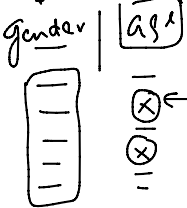

in MCAR The distribution before removing the missing values and after removing the missing values for both the Gender and Age columns remains the same

note lets see what this means :their absence doesn’t bias the data

If the missing values in the Age column are specifically for boys aged 18-30, then the data is not MCAR now

Removing these rows could bias the data because it disproportionately affects certain groups (e.g., boys aged 18-30).

and that bias as there is no boys in the country whos age is between 18-30

but in MCAR the missing values are missing completely at random and hence there is no bias in data





**MAR:  Missing data probability depends on observed data but not on unobserved data.**

suppose we have age and salary column, in age column we have all values but in salary column we have some missing values

so here the missing data from the salary column is depend on the age column means on the observed data as shown below

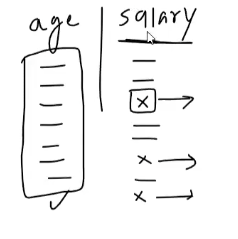

Suppose we have Age and Salary columns, and in the Age column we have all values but in the Salary column we have some missing values.

- Missing Values: Missing data in the Salary column can be explained using the Age column, as shown below.

- Observation: Younger people aged 17-29 have missing values in the Salary column, while those aged 30-60 do not.

- Reason: Missing values are due to unemployment; many younger people do not have jobs.

- Conclusion: The missingness in the Salary column is explained by the Age column(i.e observed column), so this is called MAR (Missing at Random).

# creating notes from campusx projects 


### Capstone project 2 - YouTube Comment Analysis

create ml flow tracking server - 00.55
here sir shown simpler way so watch this also along with what sir had taught in there mlops course 

using which ways we can improve baseline model - 44.40


# for column transformer, feature union and pipeline read directly from BP 154 ,and read from point 2.column transformer only 

# 1. Importing Libraries

In [4]:
import os
import numpy as np
import pandas as pd
import ast
from scipy.stats import iqr,yeojohnson, skew, kurtosis
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

import regex as re
import eda_helper_functions
import matplotlib.gridspec as gridspec
import scipy.stats as stats

import warnings
warnings.filterwarnings("ignore")

# note : missing value Imputation should be done after train-test split — but only fitted on training data.
# and also remember that whatever we do for train data do that immidiatly for test data also 
# so below visualization also do after train test split only 

In [2]:
df = pd.read_csv('3rd_after_multivariate_analysis_dataset.csv')

In [3]:
df.shape

(11894, 46)

# Null values 

In [5]:
#let's see if our dataset contains missing values.

df.isna().sum().sum()

112331

- 112331 is a big number that tells us there are a lot of missing values in dataset

In [6]:
df.isna().sum()

id                                0
url                               0
image                           888
name                              0
wholeaddress                      0
address                           0
flooring                          0
image_urls                     4249
available_units                5218
towers                         5026
locality_rank                  3831
locality_rating                 464
construction                   1056
overlooking                    3962
ownership                      3604
extra_rooms                    5296
bath                             30
parking                        6232
builder                        4273
project_name                   3495
furnish                          39
price                             0
area                              5
costpersqft                       6
property_type                     3
status                           83
lift                           5439
flat_on_floor               

In [7]:
import pandas as pd

# Null Values Analysis
def null_features(df):
    # Prepare dataset EDA values
    summary = pd.DataFrame(df.dtypes, columns=['dtypes'])
    summary = summary.reset_index()
    summary['Name'] = summary['index']
    summary = summary[['Name', 'dtypes']]
    summary['Uniques'] = df.nunique().values
    summary['Null'] = df.isna().sum().values
    summary['Null(%)'] = round((summary['Null'] / len(df) * 100), 1).astype(str) + '%'
    
    # Add a column to indicate whether the feature has missing values
    summary['Has Null'] = summary['Null'] > 0

    # Sort by Null count (descending) and Name (ascending)
    summary = summary.sort_values(by=['Null', 'Name'], ascending=[False, True])
    summary.index = range(1, len(summary) + 1)
    
    return summary

# Example usage
#null_summary = null_features(df)
#print(null_summary)
null_features(df)

,Name,dtypes,Uniques,Null,Null(%),Has Null
1,tourist,object,16,10341,86.9%,True
2,hospital,object,56,8595,72.3%,True
3,parking,float64,10,6232,52.4%,True
4,transport,object,144,6074,51.1%,True
5,balcony,float64,8,5820,48.9%,True
6,project_in_acres,float64,205,5776,48.6%,True
7,lift,float64,10,5439,45.7%,True
8,extra_rooms,object,16,5296,44.5%,True
9,available_units,float64,589,5218,43.9%,True
10,commercial_hub,object,134,5138,43.2%,True


In [8]:
#First we create a list of missing values by each feature
temp = list(df.isna().sum())

#then we create a list of columns and their missing values as inner list to a separate list
lst= []
i=0
for col in df.columns:
    insert_lst = [col,temp[i]]
    lst.append(insert_lst)
    i+=1

#finally create a dataframe
temp_df = pd.DataFrame(data=lst,columns=['Column_Name','Missing_Values'])

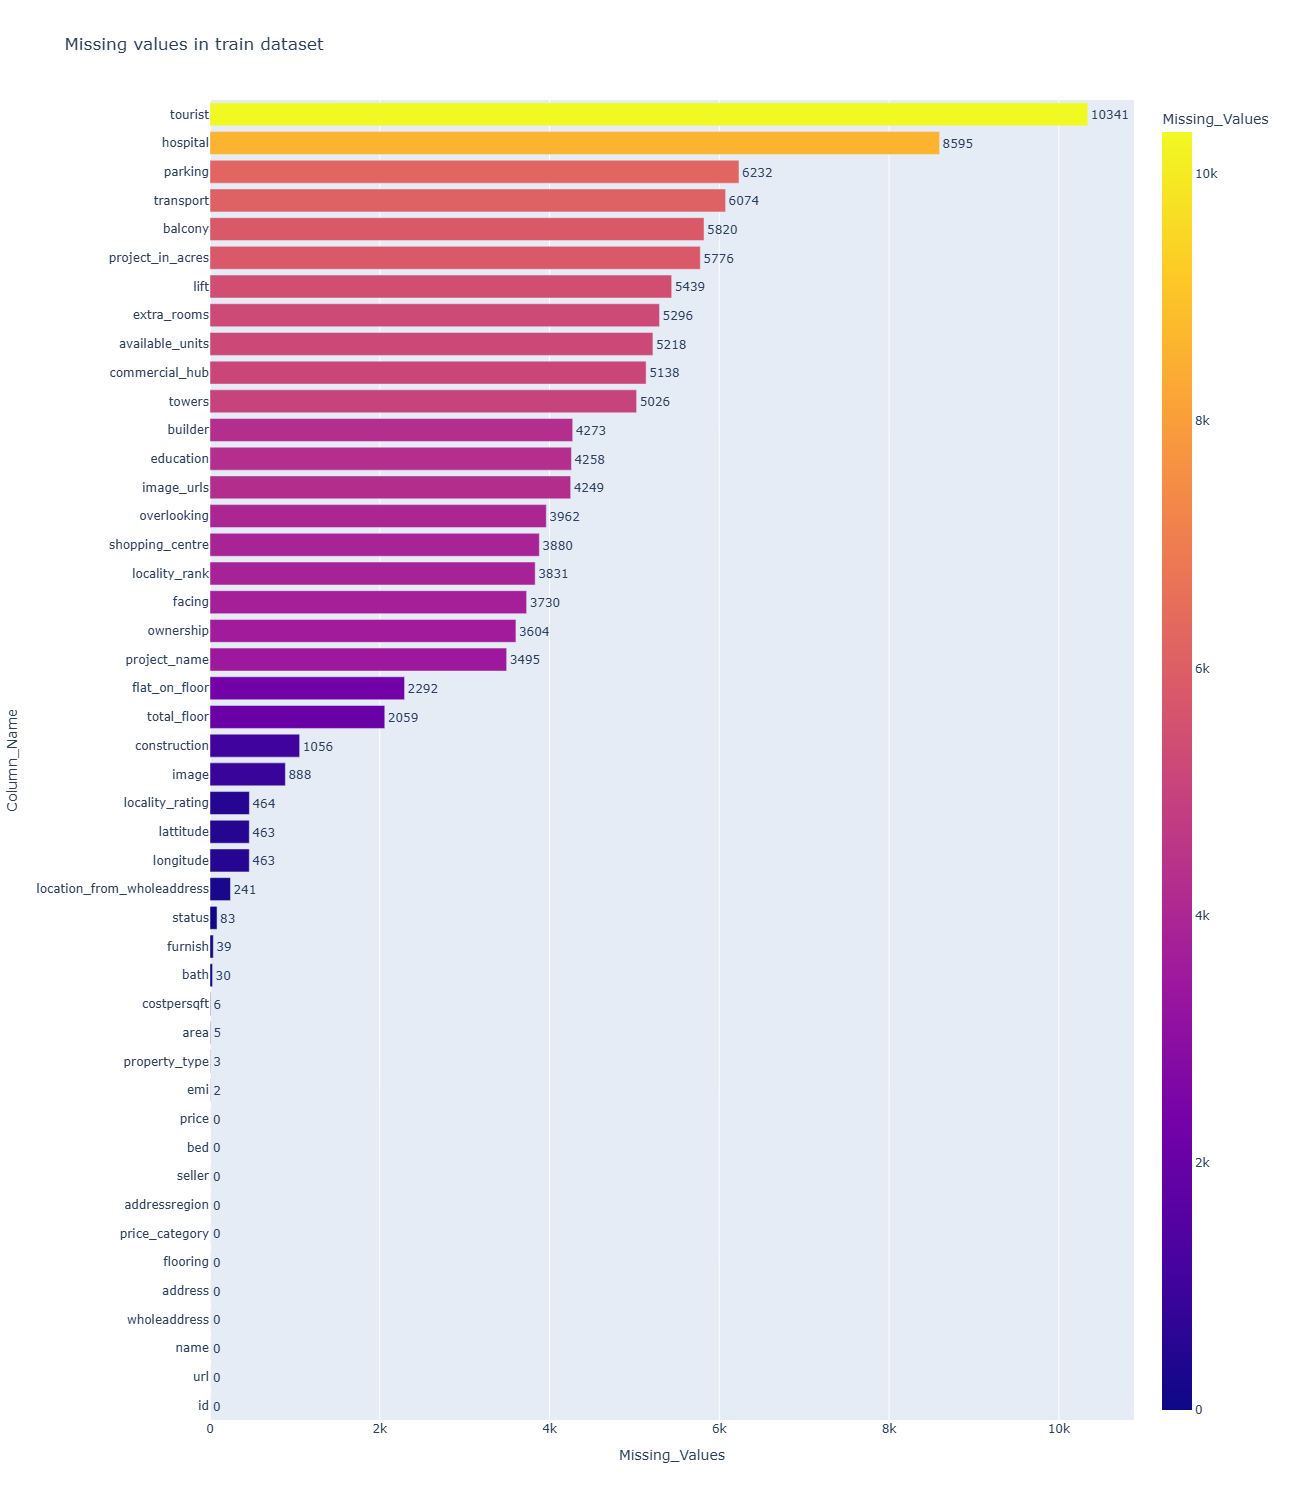

In [9]:
fig = px.bar(temp_df.sort_values(by='Missing_Values'),x='Missing_Values',y='Column_Name',
             orientation='h',height=1500,width=900,color='Missing_Values',text='Missing_Values',title='Missing values in train dataset')
fig.update_traces(textposition='outside')
fig.show()

In [10]:
#The following columns have missing values

temp_df[temp_df['Missing_Values']>0].sort_values(by='Missing_Values',ascending=False).reset_index(drop=True).style.background_gradient(cmap='Reds')

,Column_Name,Missing_Values
0,tourist,10341
1,hospital,8595
2,parking,6232
3,transport,6074
4,balcony,5820
5,project_in_acres,5776
6,lift,5439
7,extra_rooms,5296
8,available_units,5218
9,commercial_hub,5138


### obsrvation 
- total 34 columns have missing values
- total __ numerical features have missing values
- total __ categorical features have missing values

# Handling missing values



 - missingo library(bp158)
 - use heatmap and try observe -1,0,1 from bp158

 - MCAR: Missing data probability does not depend either on observed data or unobserved data, now we remove the missing values of MCAR column then Outcome: The distribution before removing the missing values and after removing the missing values for both the Gender and Age columns remains the same because the removed rows are MCAR, meaning their absence doesn’t bias the data.

 - MAR: Missing data probability depends on observed data but not on unobserved data.
 - identify MAR 2 techniques (bp158)
 - MNAR: Missing data probability depends on unobserved data, meaning the missingness is related to the value of the data that is missing.


 - There are 3 techniques from which we can handle missing values

    - 1.removing: remove all missing values

    - 2.Imputation: we trying to fill the missing values , will see techniques for this latter

    - 3.Use algorithms that can handle missing values by themselves :eg XgBoost and LightGBM

 - if MAR then we use imputation and algos
 - if MCAR then we can use all 3 i.e remove,imputation and algos

 -  Certain imputation methods are better suited to continuous data (e.g., mean imputation), while others work well with categorical data (e.g., mode imputation or using predictive models).

 - try to preserve the distribution of the data before and after filling missing valu  

- ColumnTransformer allows us to apply different transformations to different columns simultaneously within a single workflow.
- more than one tranformation on same column we can do using feature union and Feature union apply multiple transformers parallely on the entire dataset
- Pipeline apply multiple transformers sequentially on the entire dataset

from BP 154
- one imp thing is we can make custom transformer also
- when we dont have to do training on train data and apply that training on test data then that time use function approach and when we have to do training on train data and apply that training on test data that time use class approach
- so I have created some functions like this and name them as methods 

# Lets see the roadmap to handle the missing values
# Handling Missing Values:

**Roadmap to Handle Missing Values**

**1. Analyze Missingness**
- **Check % of missing values** per column and row.
- Visualize missing data patterns (e.g., heatmaps, missingno).

---

**2. Handling Methods**

**A. Removing Missing Data**
- **Column-wise**:
  - Drop columns with **too many missing values** (e.g., >40-50%).
- **Row-wise**:
  - Drop rows if they have **many missing fields** and are not critical.

---

**B. Imputing Missing Data**

i. **Univariate Imputation (Column-wise)**
- Univariate: Fill missing values in one column at a time. (e.g., Simple Imputer) 
- **Mean** (for normal distributions).
- **Median** (for skewed distributions).
- **Mode** (for categorical features).

ii. **Multivariate Imputation (Multiple columns together)**
- Multivariate Imputation: It is a method used to fill in missing values across multiple columns simultaneously.
- **KNN Imputer** (uses nearest neighbors).
- **Iterative Imputer** (models each feature with missing values as a function of other features).

---

**C. Statistical & Machine Learning Techniques**

- **Mean / Median / Mode Imputation** (basic stats methods).
- **Regression Imputation** (predict missing using other features).
- **Multiple Imputation (MICE)** (generate multiple filled datasets to reduce bias).
- **Random Forest Imputer** (tree-based estimation).
- **XGBoost / LightGBM-based Imputation** (powerful gradient boosting methods for complex patterns).

---

**3. Evaluate Impact of Imputation**
- Compare data distribution **before & after** imputation.
- Check for **data leakage** risk (especially with target leakage).

---

**4. Pipeline Integration**
- Integrate chosen imputation methods into **sklearn Pipelines** for consistency during model training and prediction.

lets see 1st 7 notebooks which I have downloded what they did   
from a. eda-and-prediction-of-house-price
- they check box plot then mean and median and then fill the missing values by median for both train and test dataset,remember that we fill missing values using median when we have skewed distribution 
- if feature like garage , if in this column if there are missing values then we fill that using no garage ,becoz we cant predict properties have garage or not

from c.house-price-prediction
- Since all features are categorical, using mode imputation (most frequent value) is the best choice. we can't take the mean nor the median
- As mentioned before that the 'NA' value in many columns represent the absence of that feature for a particular house, we will replace those null values with None. 'None' for categorical feature and 0 for numerical feature.
- features['MSZoning'] = features.groupby('MSSubClass')['MSZoning'].transform(lambda x: x.fillna(x.mode()[0]))
   - for above code : To fill missing values (NaN) in the MSZoning column. But instead of considering the whole MSSubClass column, what they did is they fill missing values based on the mode of each group defined by MSSubClass.

When you have **too many categories in a nominal categorical column**, it can lead to issues like:

* **High dimensionality** if you one-hot encode.
* **Sparsity** in data.
* **Overfitting** in models.

Here are common ways to handle it:

---

### ✅ **1. Frequency / Count Encoding**

* Replace each category with its frequency (number of times it appears).
* Good when order doesn’t matter but frequency is meaningful.

```python
freq_map = df['column'].value_counts().to_dict()
df['column_encoded'] = df['column'].map(freq_map)
```

---

### ✅ **2. Grouping Rare Categories**

* Group infrequent categories into a single label like `'Other'`.

```python
threshold = 100  # minimum count to keep
value_counts = df['column'].value_counts()
common = value_counts[value_counts >= threshold].index
df['column_grouped'] = df['column'].apply(lambda x: x if x in common else 'Other')
```

---

### ✅ **3. Target Encoding**

* Replace each category with the **mean of the target variable** (only for training set).
* Be careful to avoid **data leakage** (use cross-validation or holdout mean).

---

### ✅ **4. Embedding (for Deep Learning)**

* Use embeddings to learn a dense representation of high-cardinality categories.
* Requires a neural network-based model.

---

### ✅ **5. Hashing Encoding**

* Hash categories into a fixed number of bins.
* Useful when cardinality is extremely high (e.g., user IDs, product codes).

---

Let me know your exact use case (e.g., how many categories, what model you are using), and I can suggest the best fit.


In [11]:
#missing value in percentage
missing_values_percentage = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of missing values in each column:")
print(missing_values_percentage)


Percentage of missing values in each column:
id                             0.000000
url                            0.000000
image                          7.465949
name                           0.000000
wholeaddress                   0.000000
address                        0.000000
flooring                       0.000000
image_urls                    35.723894
available_units               43.870859
towers                        42.256600
locality_rank                 32.209517
locality_rating                3.901127
construction                   8.878426
overlooking                   33.310913
ownership                     30.300992
extra_rooms                   44.526652
bath                           0.252228
parking                       52.396166
builder                       35.925677
project_name                  29.384564
furnish                        0.327896
price                          0.000000
area                           0.042038
costpersqft                    0.0

# Missingo for Missing Values

In [8]:
df.shape

(11898, 49)

<Axes: >

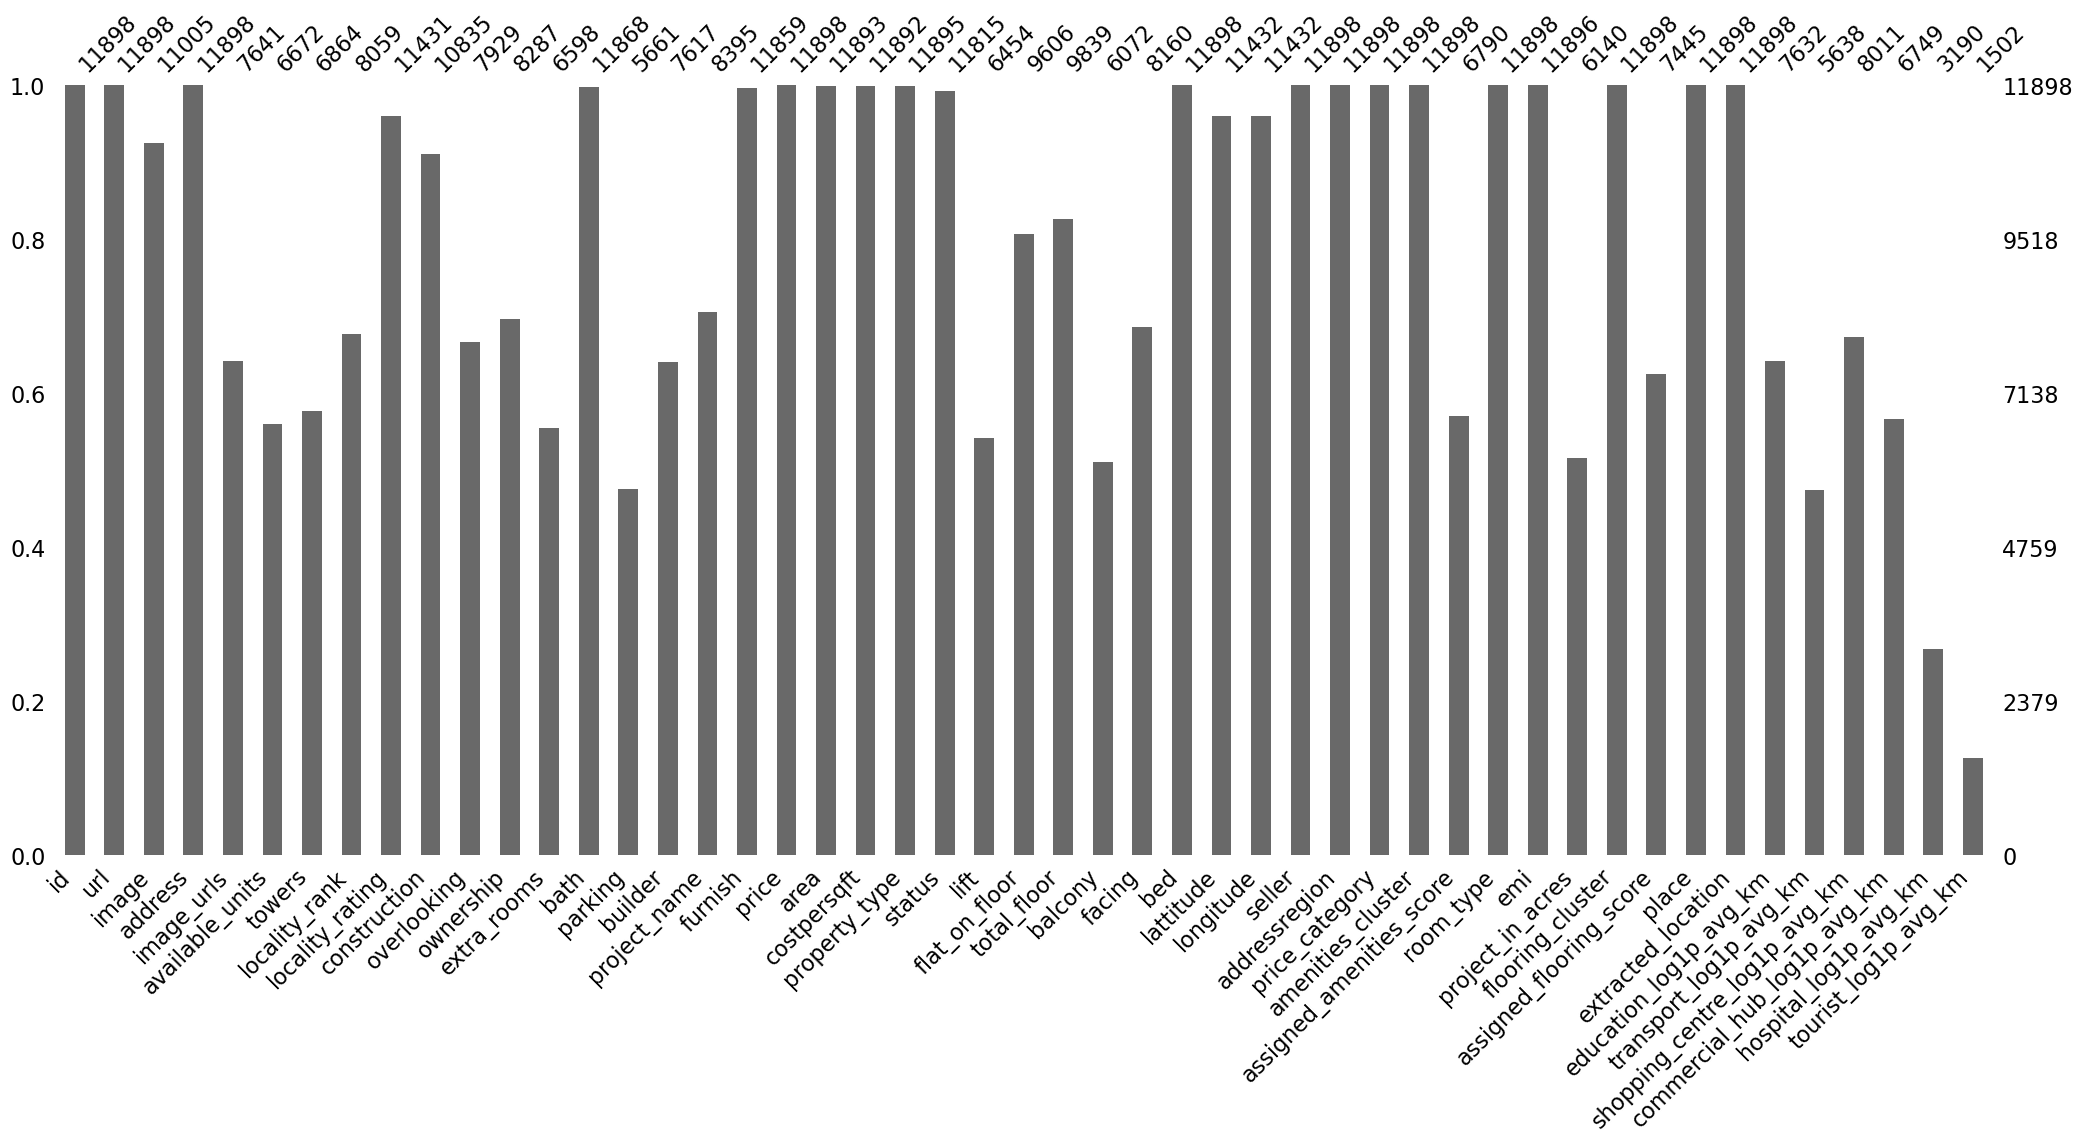

In [9]:
# Bar plot to visualize missing values
msno.bar(df)

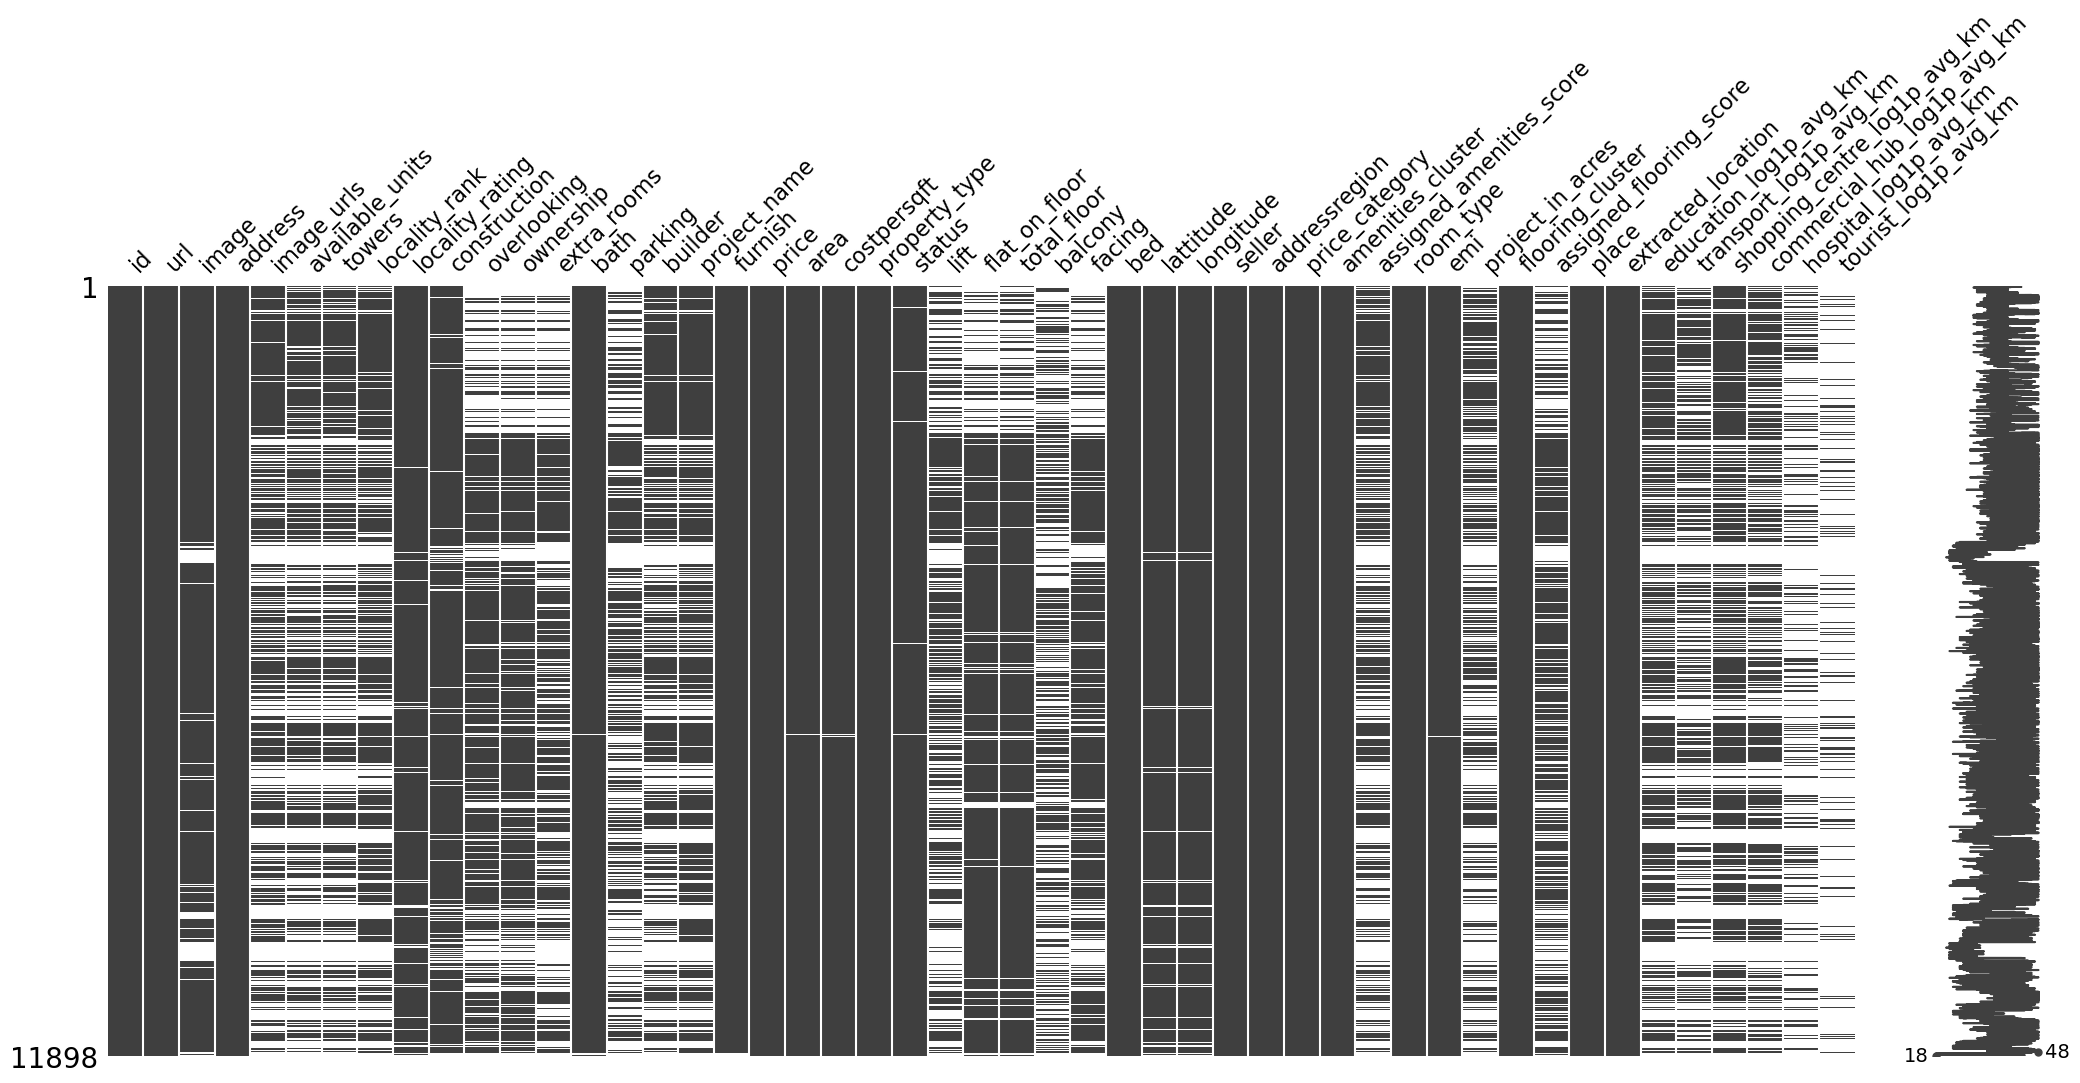

In [10]:
# Matrix chart to visualize missing values
msno.matrix(df)
plt.show()

# Observation from above graph

write where you find the similarity of missing between 2 or many columns 


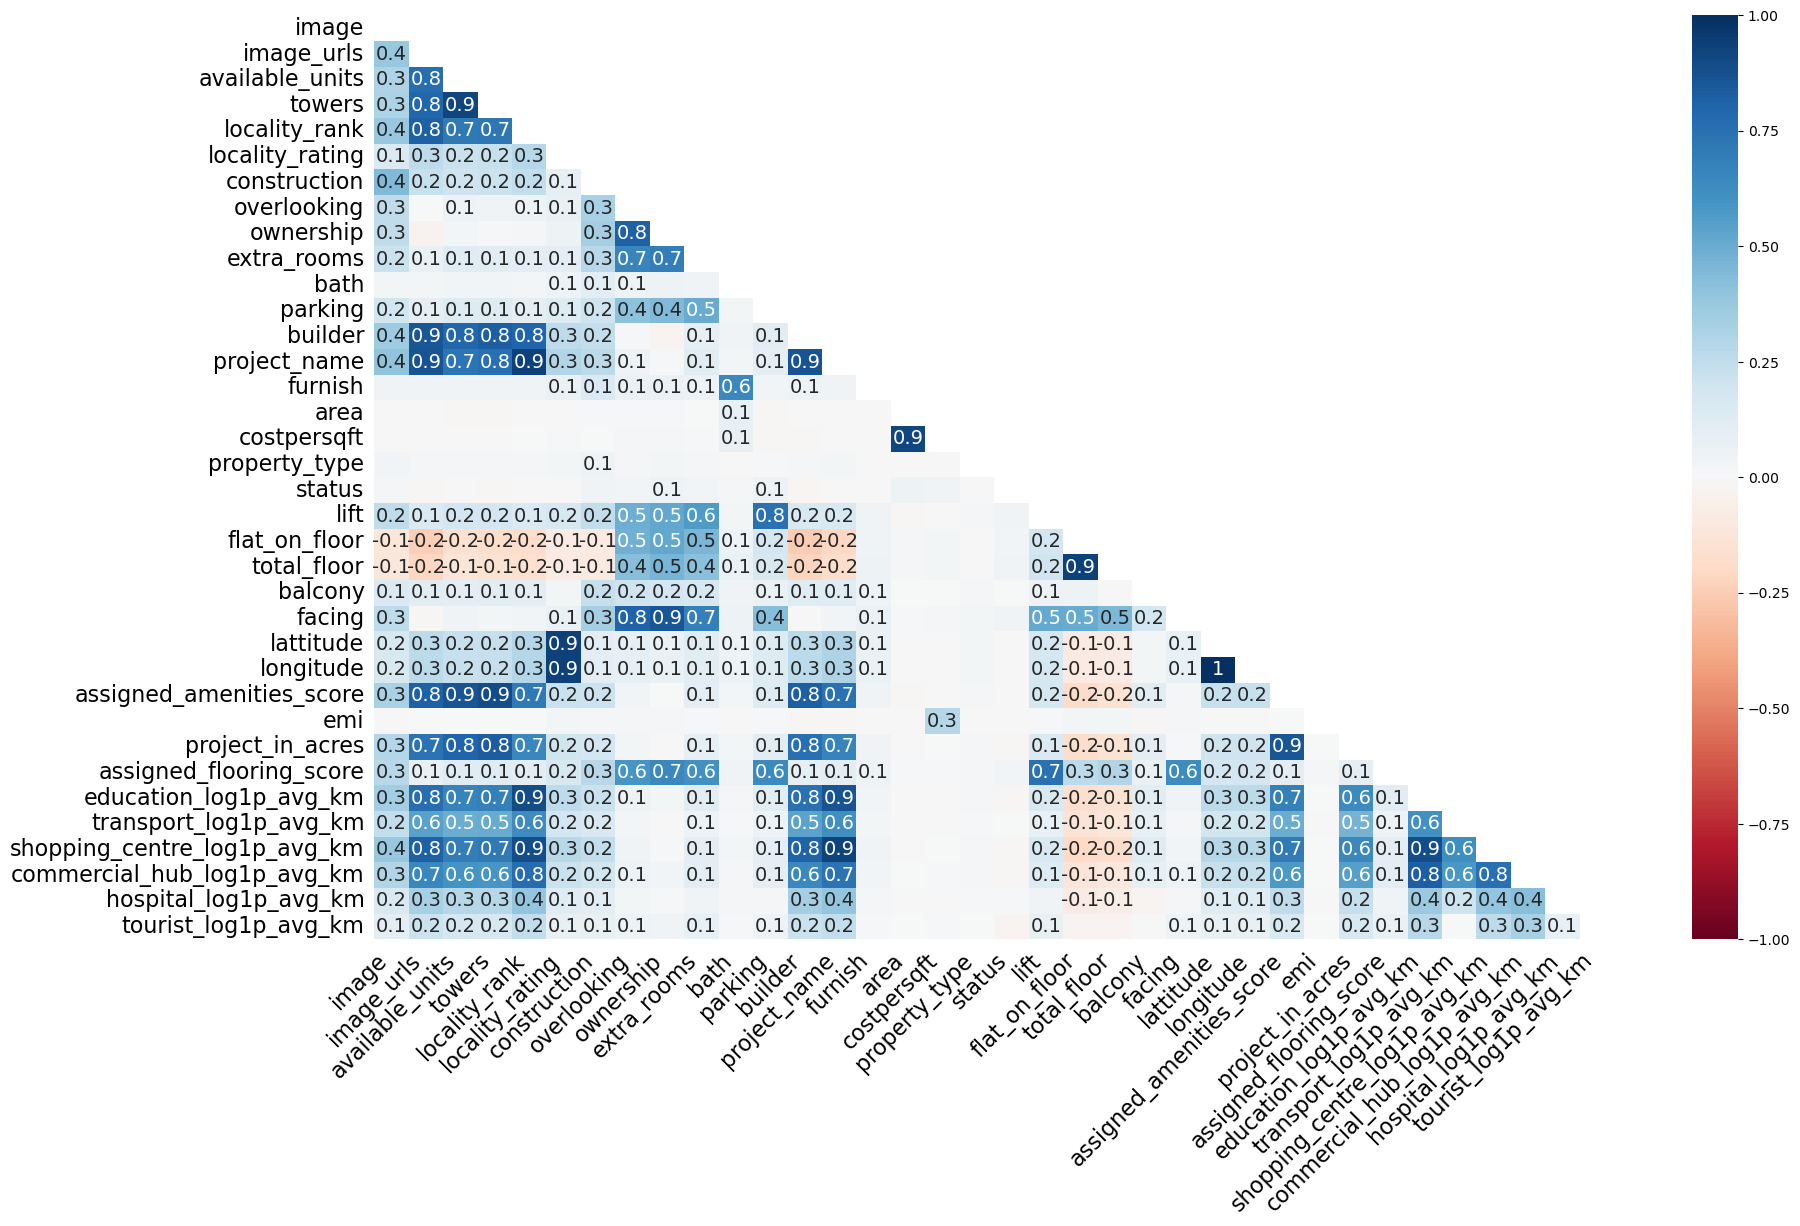

In [11]:
# Heatmap to visualize the correlation of missingness between columns
msno.heatmap(df)
plt.show()

In [12]:
#explain above also 

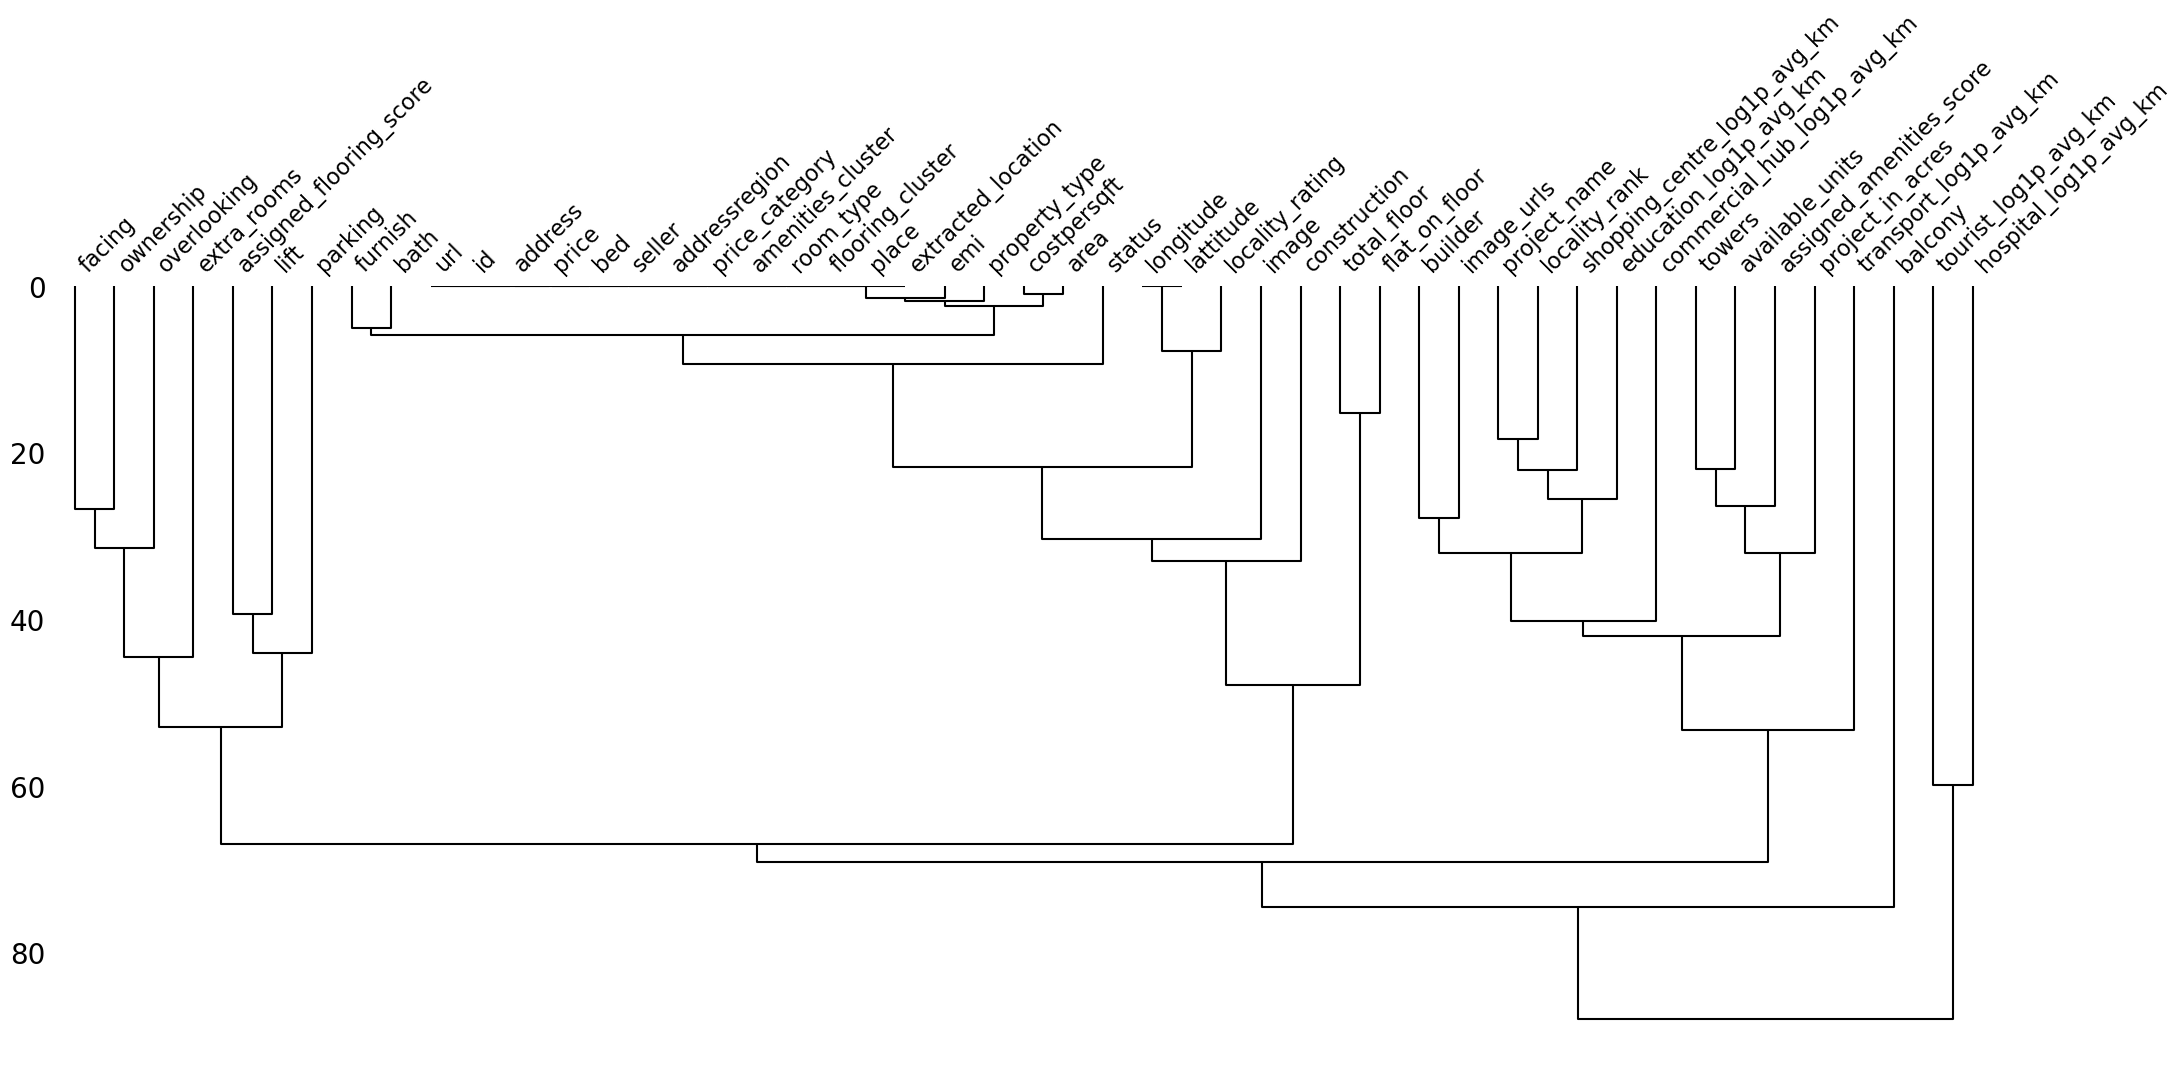

In [13]:
# Dendrogram to visualize the hierarchical clustering of missing values
msno.dendrogram(df)
plt.show()

 so missing values in the real estate data may becoz of the following reasons   
1)Unavailability: Some details are genuinely not applicable to all properties (e.g., no extra rooms or amenities).   
2)Human Error: Mistakes in data entry, oversight, or skipping fields during data collection.  
3)lack of information   
4)Confidentiality: Certain data points (e.g., seller details, builder names) may be intentionally omitted.  


<Axes: xlabel='bed', ylabel='Count'>

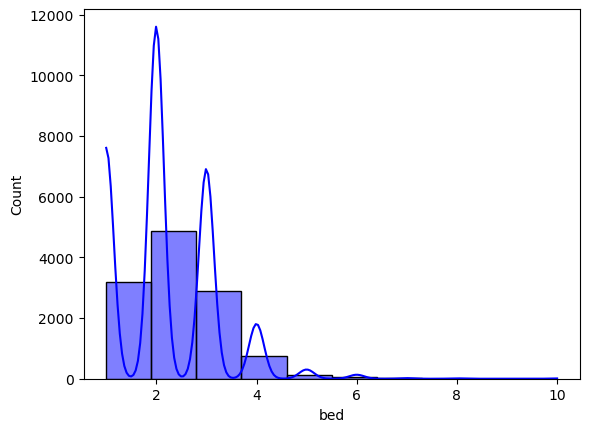

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['bed'], bins=10, kde=True, color='blue')